In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# AMVERSO

/tmp/ipython-input-1376572729.py:31: UserWarning: Argument(s) 'value' are not valid for transform Rotate
  A.Rotate(limit=25, border_mode=cv2.BORDER_CONSTANT, value=(0, 0, 0), p=0.6),
/tmp/ipython-input-1376572729.py:36: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 25.0), p=0.2),
/tmp/ipython-input-1376572729.py:38: UserWarning: Argument(s) 'pad_mode, pad_val' are not valid for transform Perspective
  A.Perspective(p=0.25, pad_mode=cv2.BORDER_CONSTANT, pad_val=(0, 0, 0)),
/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipython-input-1376572729.py:39: UserWarning: Argument(s) 'value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.12, rotate_limit=10, p=0.35,


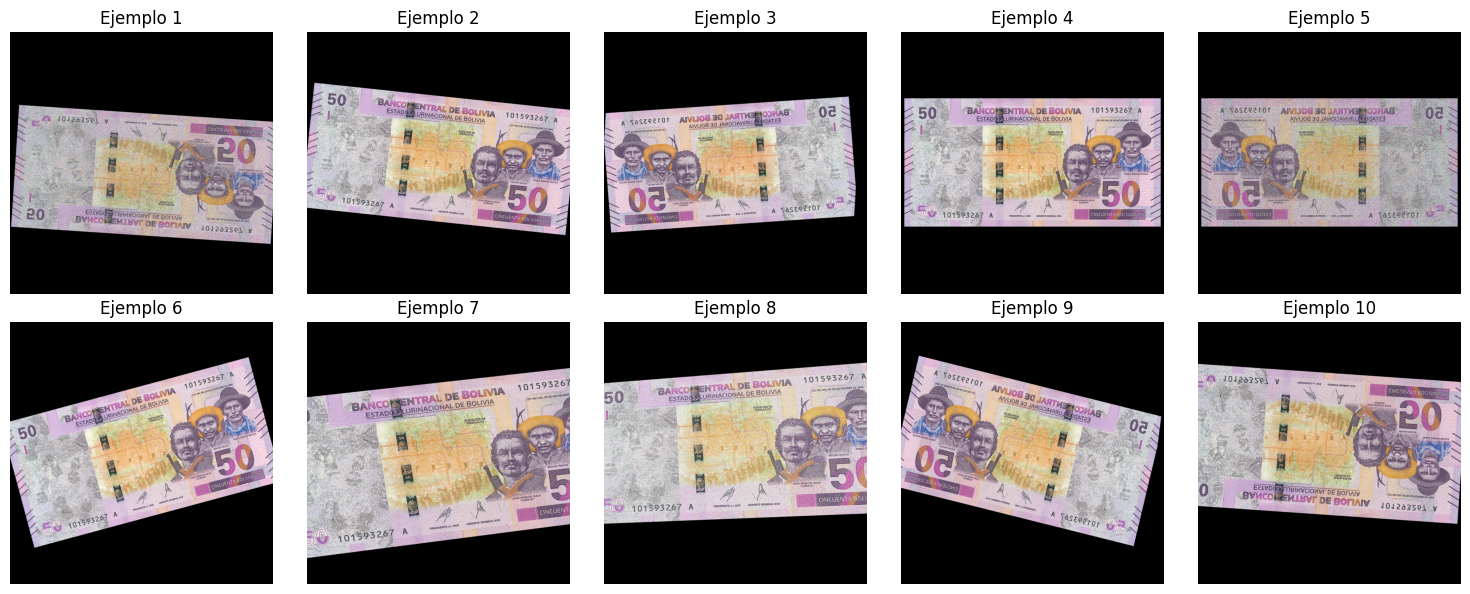

In [2]:
import cv2
import albumentations as A
import numpy as np
import matplotlib.pyplot as plt
import os

# Ruta de la imagen base
image_path = "/content/drive/MyDrive/SIS420-IA/Proyecto/Billetes/Serie A/50/50_A.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

canvas_size = 2240

def place_on_canvas(img, canvas_size=2240):
    """Coloca la imagen centrada sobre un lienzo negro."""
    h, w = img.shape[:2]
    canvas = np.zeros((canvas_size, canvas_size, 3), dtype=np.uint8)  # fondo negro
    y = (canvas_size - h) // 2
    x = (canvas_size - w) // 2
    canvas[y:y+h, x:x+w] = img
    return canvas

# Imagen base ya sobre fondo negro
base_canvas = place_on_canvas(image, canvas_size)

# Máscara binaria (1 en la región del billete, 0 en el fondo negro)
base_mask = (np.any(base_canvas != 0, axis=2)).astype(np.uint8) * 255

# Pipeline de augmentations con fondo negro y cambios cromáticos suaves
transform = A.Compose([
    A.Rotate(limit=25, border_mode=cv2.BORDER_CONSTANT, value=(0, 0, 0), p=0.6),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomBrightnessContrast(brightness_limit=0.08, contrast_limit=0.08, p=0.5),  # más suave
    A.HueSaturationValue(hue_shift_limit=4, sat_shift_limit=6, val_shift_limit=4, p=0.15),  # muy leve
    A.GaussNoise(var_limit=(5.0, 25.0), p=0.2),
    A.MotionBlur(blur_limit=5, p=0.12),
    A.Perspective(p=0.25, pad_mode=cv2.BORDER_CONSTANT, pad_val=(0, 0, 0)),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.12, rotate_limit=10, p=0.35,
                       border_mode=cv2.BORDER_CONSTANT, value=(0, 0, 0))
], additional_targets={'mask': 'mask'})

# Carpeta de salida
os.makedirs("augmented", exist_ok=True)

# Generar 200 imágenes aumentadas
for i in range(200):
    out = transform(image=base_canvas, mask=base_mask)
    aug_img = out["image"]
    aug_mask = out["mask"]

    # Fondo negro puro donde no hay billete
    aug_img[aug_mask == 0] = 0

    # Corrección de interpolaciones blancas (por rotaciones o perspectiva)
    near_white = np.all(aug_img > 247, axis=2)
    aug_img[near_white] = 0

    # Guardar en PNG para evitar artefactos
    cv2.imwrite(f"augmented/billete_{i:03d}.png", cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR))

# Mostrar 10 ejemplos
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for idx, ax in enumerate(axes.flat):
    out = transform(image=base_canvas, mask=base_mask)
    aug = out["image"]
    mask = out["mask"]
    aug[mask == 0] = 0
    near_white = np.all(aug > 247, axis=2)
    aug[near_white] = 0
    ax.imshow(aug)
    ax.axis("off")
    ax.set_title(f"Ejemplo {idx+1}")
plt.tight_layout()
plt.show()

# 64x64

Se encontraron 200 imágenes en 'augmented'
Redimensionando a 64x64 y guardando en:
/content/drive/MyDrive/SIS420-IA/Proyecto/Billetes/Serie A/50/augmented_A_64


Redimensionando: 100%|██████████| 200/200 [00:28<00:00,  7.02it/s]


¡Listo! 200 imágenes guardadas en 64x64 en Drive.

Mostrando las primeras 10 imágenes redimensionadas...


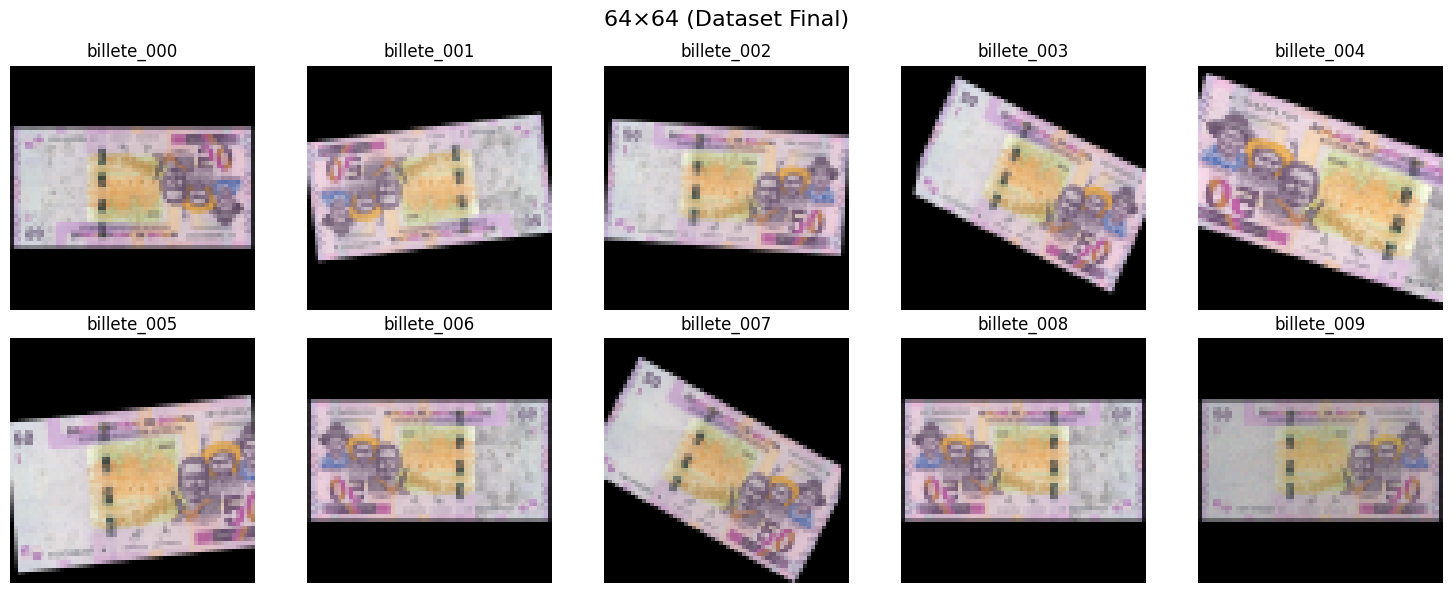

In [3]:
import cv2
import os
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

# === RUTAS ===
input_dir = "augmented"  # ← Carpeta temporal con las 200 imágenes grandes (2240x2240)
output_dir = "/content/drive/MyDrive/SIS420-IA/Proyecto/Billetes/Serie A/50/augmented_A_64"

target_size = 64  # ← Tamaño final: 64x64

# Crear carpeta de salida en Drive
os.makedirs(output_dir, exist_ok=True)

# Obtener lista de imágenes
image_files = sorted([f for f in os.listdir(input_dir) if f.endswith('.png')])

print(f"Se encontraron {len(image_files)} imágenes en '{input_dir}'")
print(f"Redimensionando a {target_size}x{target_size} y guardando en:\n{output_dir}")

# === BUCLE DE REDIMENSIONAMIENTO ===
for filename in tqdm(image_files, desc="Redimensionando"):
    # Leer imagen
    img_path = os.path.join(input_dir, filename)
    img = cv2.imread(img_path)
    if img is None:
        print(f"Error al leer: {filename}")
        continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Redimensionar
    img_resized = cv2.resize(img_rgb, (target_size, target_size), interpolation=cv2.INTER_AREA)

    # Fondo negro puro (eliminar artefactos)
    mask = np.any(img_resized > 0, axis=2)
    img_resized[~mask] = 0

    # Guardar en Drive
    output_path = os.path.join(output_dir, filename)
    cv2.imwrite(output_path, cv2.cvtColor(img_resized, cv2.COLOR_RGB2BGR))

print(f"¡Listo! {len(image_files)} imágenes guardadas en 64x64 en Drive.")

# === MOSTRAR 10 EJEMPLOS REDIMENSIONADOS ===
print("\nMostrando las primeras 10 imágenes redimensionadas...")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
selected_files = sorted(os.listdir(output_dir))[:10]

for idx, ax in enumerate(axes.flat):
    img_path = os.path.join(output_dir, selected_files[idx])
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"{selected_files[idx].split('.')[0]}")

plt.suptitle(f"64×64 (Dataset Final)", fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

# 128x128

Se encontraron 200 imágenes en 'augmented'
Redimensionando a 128x128 y guardando en:
/content/drive/MyDrive/SIS420-IA/Proyecto/Billetes/Serie A/50/augmented_A_128


Redimensionando: 100%|██████████| 200/200 [00:31<00:00,  6.33it/s]


¡Listo! 200 imágenes guardadas en 128x128 en Drive.

Mostrando las primeras 10 imágenes redimensionadas (128x128)...


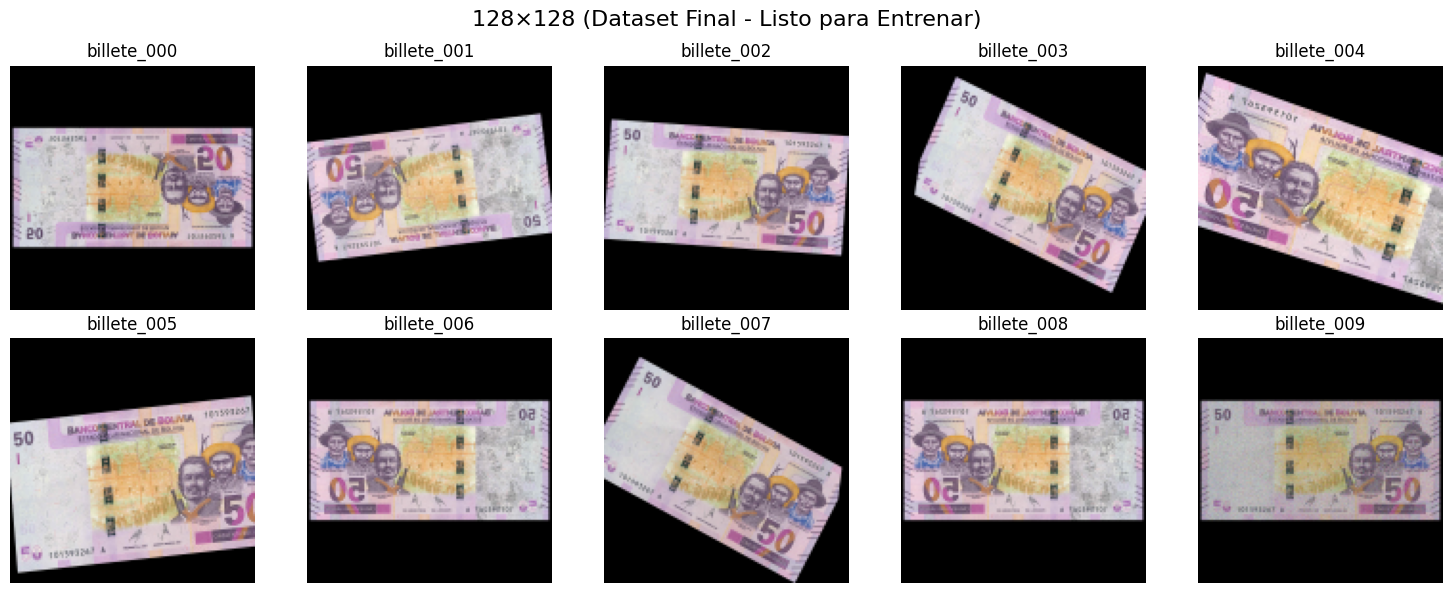

In [4]:
import cv2
import os
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

# === RUTAS ===
input_dir = "augmented"  # ← Carpeta temporal con 200 imágenes grandes (2240x2240)
output_dir = "/content/drive/MyDrive/SIS420-IA/Proyecto/Billetes/Serie A/50/augmented_A_128"

target_size = 128  # ← Tamaño final: 128x128

# Crear carpeta de salida en Drive
os.makedirs(output_dir, exist_ok=True)

# Obtener lista de imágenes
image_files = sorted([f for f in os.listdir(input_dir) if f.endswith('.png')])

print(f"Se encontraron {len(image_files)} imágenes en '{input_dir}'")
print(f"Redimensionando a {target_size}x{target_size} y guardando en:\n{output_dir}")

# === BUCLE DE REDIMENSIONAMIENTO ===
for filename in tqdm(image_files, desc="Redimensionando"):
    # Leer imagen
    img_path = os.path.join(input_dir, filename)
    img = cv2.imread(img_path)
    if img is None:
        print(f"Error al leer: {filename}")
        continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Redimensionar con interpolación de alta calidad
    img_resized = cv2.resize(img_rgb, (target_size, target_size), interpolation=cv2.INTER_AREA)

    # Fondo negro puro (eliminar artefactos)
    mask = np.any(img_resized > 0, axis=2)
    img_resized[~mask] = 0

    # Guardar en Drive
    output_path = os.path.join(output_dir, filename)
    cv2.imwrite(output_path, cv2.cvtColor(img_resized, cv2.COLOR_RGB2BGR))

print(f"¡Listo! {len(image_files)} imágenes guardadas en 128x128 en Drive.")

# === MOSTRAR 10 EJEMPLOS REDIMENSIONADOS (128x128) ===
print("\nMostrando las primeras 10 imágenes redimensionadas (128x128)...")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
selected_files = sorted(os.listdir(output_dir))[:10]

for idx, ax in enumerate(axes.flat):
    img_path = os.path.join(output_dir, selected_files[idx])
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"{selected_files[idx].split('.')[0]}")

plt.suptitle("128×128 (Dataset Final - Listo para Entrenar)", fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

In [5]:
!rm -rf augmented

# REVERSO

/tmp/ipython-input-2515870076.py:31: UserWarning: Argument(s) 'value' are not valid for transform Rotate
  A.Rotate(limit=25, border_mode=cv2.BORDER_CONSTANT, value=(0, 0, 0), p=0.6),
/tmp/ipython-input-2515870076.py:36: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 25.0), p=0.2),
/tmp/ipython-input-2515870076.py:38: UserWarning: Argument(s) 'pad_mode, pad_val' are not valid for transform Perspective
  A.Perspective(p=0.25, pad_mode=cv2.BORDER_CONSTANT, pad_val=(0, 0, 0)),
/tmp/ipython-input-2515870076.py:39: UserWarning: Argument(s) 'value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.12, rotate_limit=10, p=0.35,


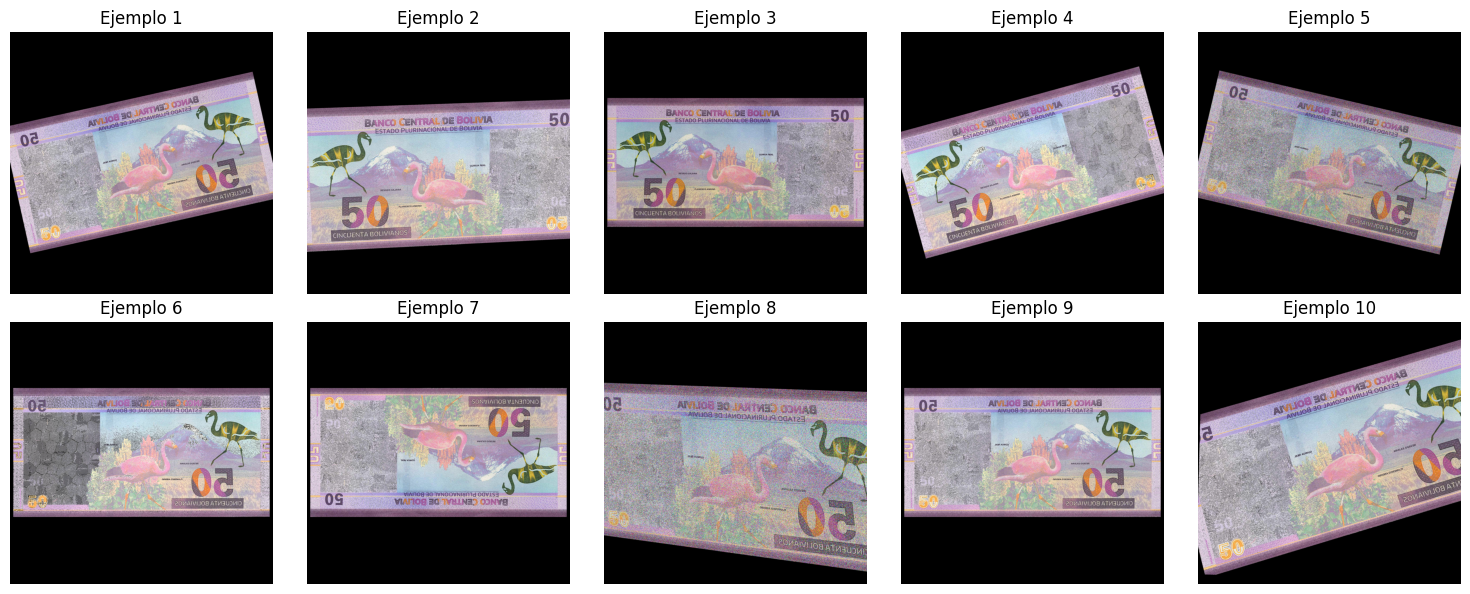

In [6]:
import cv2
import albumentations as A
import numpy as np
import matplotlib.pyplot as plt
import os

# Ruta de la imagen base
image_path = "/content/drive/MyDrive/SIS420-IA/Proyecto/Billetes/Serie A/50/50_R.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

canvas_size = 2240

def place_on_canvas(img, canvas_size=2240):
    """Coloca la imagen centrada sobre un lienzo negro."""
    h, w = img.shape[:2]
    canvas = np.zeros((canvas_size, canvas_size, 3), dtype=np.uint8)  # fondo negro
    y = (canvas_size - h) // 2
    x = (canvas_size - w) // 2
    canvas[y:y+h, x:x+w] = img
    return canvas

# Imagen base ya sobre fondo negro
base_canvas = place_on_canvas(image, canvas_size)

# Máscara binaria (1 en la región del billete, 0 en el fondo negro)
base_mask = (np.any(base_canvas != 0, axis=2)).astype(np.uint8) * 255

# Pipeline de augmentations con fondo negro y cambios cromáticos suaves
transform = A.Compose([
    A.Rotate(limit=25, border_mode=cv2.BORDER_CONSTANT, value=(0, 0, 0), p=0.6),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomBrightnessContrast(brightness_limit=0.08, contrast_limit=0.08, p=0.5),  # más suave
    A.HueSaturationValue(hue_shift_limit=4, sat_shift_limit=6, val_shift_limit=4, p=0.15),  # muy leve
    A.GaussNoise(var_limit=(5.0, 25.0), p=0.2),
    A.MotionBlur(blur_limit=5, p=0.12),
    A.Perspective(p=0.25, pad_mode=cv2.BORDER_CONSTANT, pad_val=(0, 0, 0)),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.12, rotate_limit=10, p=0.35,
                       border_mode=cv2.BORDER_CONSTANT, value=(0, 0, 0))
], additional_targets={'mask': 'mask'})

# Carpeta de salida
os.makedirs("augmented", exist_ok=True)

# Generar 200 imágenes aumentadas
for i in range(200):
    out = transform(image=base_canvas, mask=base_mask)
    aug_img = out["image"]
    aug_mask = out["mask"]

    # Fondo negro puro donde no hay billete
    aug_img[aug_mask == 0] = 0

    # Corrección de interpolaciones blancas (por rotaciones o perspectiva)
    near_white = np.all(aug_img > 247, axis=2)
    aug_img[near_white] = 0

    # Guardar en PNG para evitar artefactos
    cv2.imwrite(f"augmented/billete_{i:03d}.png", cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR))

# Mostrar 10 ejemplos
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for idx, ax in enumerate(axes.flat):
    out = transform(image=base_canvas, mask=base_mask)
    aug = out["image"]
    mask = out["mask"]
    aug[mask == 0] = 0
    near_white = np.all(aug > 247, axis=2)
    aug[near_white] = 0
    ax.imshow(aug)
    ax.axis("off")
    ax.set_title(f"Ejemplo {idx+1}")
plt.tight_layout()
plt.show()

# 64x64

Se encontraron 200 imágenes en 'augmented'
Redimensionando a 64x64 y guardando en:
/content/drive/MyDrive/SIS420-IA/Proyecto/Billetes/Serie A/50/augmented_R_64


Redimensionando: 100%|██████████| 200/200 [00:28<00:00,  7.00it/s]


¡Listo! 200 imágenes guardadas en 64x64 en Drive.

Mostrando las primeras 10 imágenes redimensionadas...


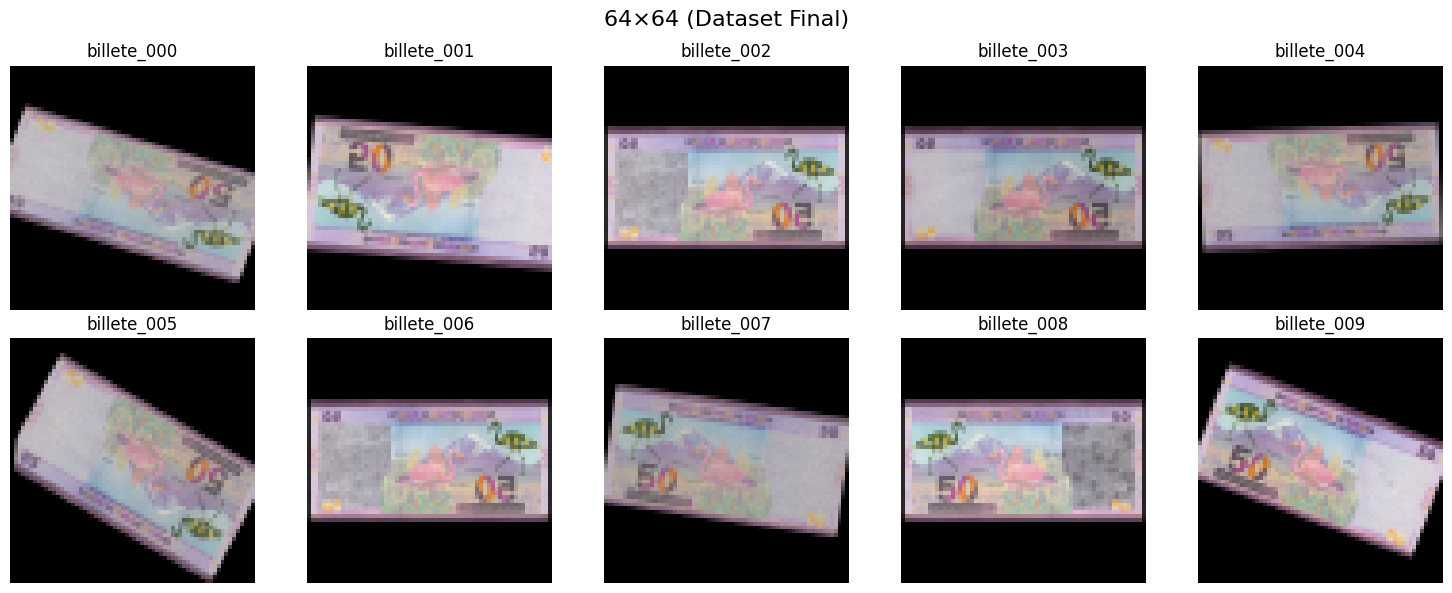

In [8]:
import cv2
import os
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

# === RUTAS ===
input_dir = "augmented"  # ← Carpeta temporal con las 200 imágenes grandes (2240x2240)
output_dir = "/content/drive/MyDrive/SIS420-IA/Proyecto/Billetes/Serie A/50/augmented_R_64"

target_size = 64  # ← Tamaño final: 64x64

# Crear carpeta de salida en Drive
os.makedirs(output_dir, exist_ok=True)

# Obtener lista de imágenes
image_files = sorted([f for f in os.listdir(input_dir) if f.endswith('.png')])

print(f"Se encontraron {len(image_files)} imágenes en '{input_dir}'")
print(f"Redimensionando a {target_size}x{target_size} y guardando en:\n{output_dir}")

# === BUCLE DE REDIMENSIONAMIENTO ===
for filename in tqdm(image_files, desc="Redimensionando"):
    # Leer imagen
    img_path = os.path.join(input_dir, filename)
    img = cv2.imread(img_path)
    if img is None:
        print(f"Error al leer: {filename}")
        continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Redimensionar
    img_resized = cv2.resize(img_rgb, (target_size, target_size), interpolation=cv2.INTER_AREA)

    # Fondo negro puro (eliminar artefactos)
    mask = np.any(img_resized > 0, axis=2)
    img_resized[~mask] = 0

    # Guardar en Drive
    output_path = os.path.join(output_dir, filename)
    cv2.imwrite(output_path, cv2.cvtColor(img_resized, cv2.COLOR_RGB2BGR))

print(f"¡Listo! {len(image_files)} imágenes guardadas en 64x64 en Drive.")

# === MOSTRAR 10 EJEMPLOS REDIMENSIONADOS ===
print("\nMostrando las primeras 10 imágenes redimensionadas...")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
selected_files = sorted(os.listdir(output_dir))[:10]

for idx, ax in enumerate(axes.flat):
    img_path = os.path.join(output_dir, selected_files[idx])
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"{selected_files[idx].split('.')[0]}")

plt.suptitle(f"64×64 (Dataset Final)", fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

# 128x128

Se encontraron 200 imágenes en 'augmented'
Redimensionando a 128x128 y guardando en:
/content/drive/MyDrive/SIS420-IA/Proyecto/Billetes/Serie A/50/augmented_R_128


Redimensionando: 100%|██████████| 200/200 [00:31<00:00,  6.37it/s]


¡Listo! 200 imágenes guardadas en 128x128 en Drive.

Mostrando las primeras 10 imágenes redimensionadas (128x128)...


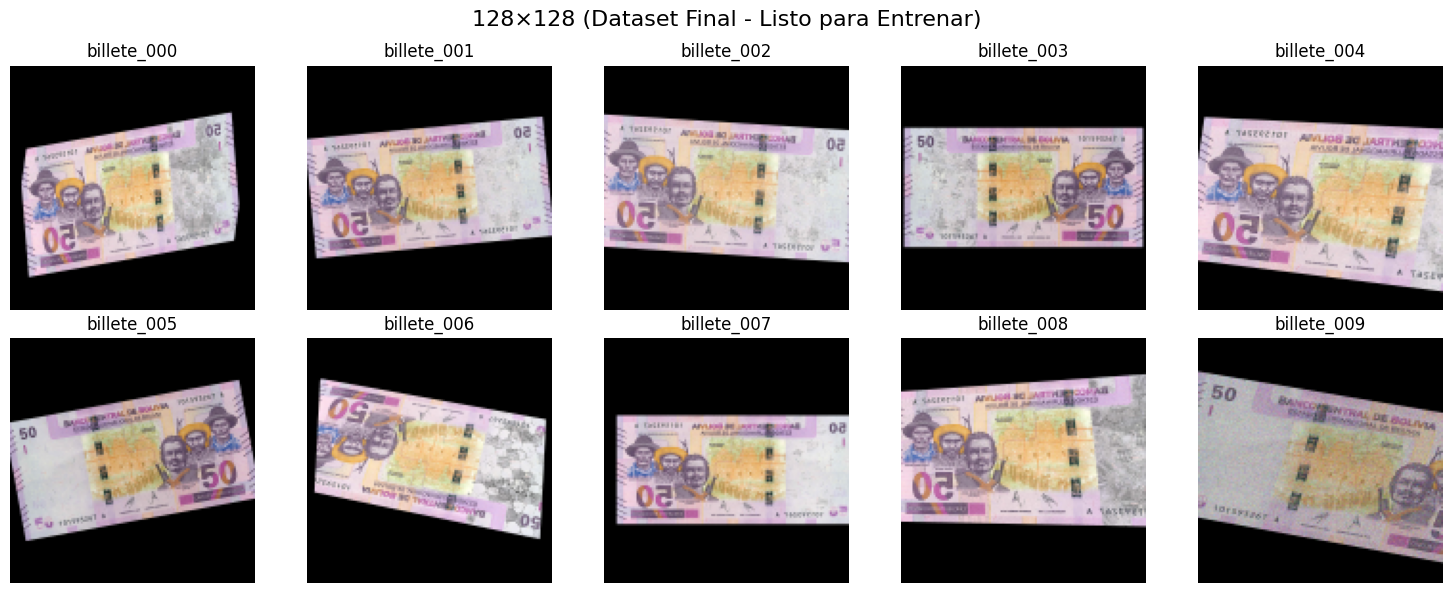

In [9]:
import cv2
import os
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

# === RUTAS ===
input_dir = "augmented"  # ← Carpeta temporal con 200 imágenes grandes (2240x2240)
output_dir = "/content/drive/MyDrive/SIS420-IA/Proyecto/Billetes/Serie A/50/augmented_R_128"

target_size = 128  # ← Tamaño final: 128x128

# Crear carpeta de salida en Drive
os.makedirs(output_dir, exist_ok=True)

# Obtener lista de imágenes
image_files = sorted([f for f in os.listdir(input_dir) if f.endswith('.png')])

print(f"Se encontraron {len(image_files)} imágenes en '{input_dir}'")
print(f"Redimensionando a {target_size}x{target_size} y guardando en:\n{output_dir}")

# === BUCLE DE REDIMENSIONAMIENTO ===
for filename in tqdm(image_files, desc="Redimensionando"):
    # Leer imagen
    img_path = os.path.join(input_dir, filename)
    img = cv2.imread(img_path)
    if img is None:
        print(f"Error al leer: {filename}")
        continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Redimensionar con interpolación de alta calidad
    img_resized = cv2.resize(img_rgb, (target_size, target_size), interpolation=cv2.INTER_AREA)

    # Fondo negro puro (eliminar artefactos)
    mask = np.any(img_resized > 0, axis=2)
    img_resized[~mask] = 0

    # Guardar en Drive
    output_path = os.path.join(output_dir, filename)
    cv2.imwrite(output_path, cv2.cvtColor(img_resized, cv2.COLOR_RGB2BGR))

print(f"¡Listo! {len(image_files)} imágenes guardadas en 128x128 en Drive.")

# === MOSTRAR 10 EJEMPLOS REDIMENSIONADOS (128x128) ===
print("\nMostrando las primeras 10 imágenes redimensionadas (128x128)...")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
selected_files = sorted(os.listdir(output_dir))[:10]

for idx, ax in enumerate(axes.flat):
    img_path = os.path.join(output_dir, selected_files[idx])
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"{selected_files[idx].split('.')[0]}")

plt.suptitle("128×128 (Dataset Final - Listo para Entrenar)", fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

In [10]:
!rm -rf augmented